# Level 1 Task 1

## Exploratory Data Analysis (EDA) on Retail Sales Dataset

**Internship:** Oasis Infobyte

**Name:** Your Name

**Date:** July 2026


In [21]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [22]:


df = pd.read_csv("retail_sales_dataset.csv")

In [23]:


df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [24]:


print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 11)


In [25]:


df.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

In [26]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


In [27]:
# Check Missing Values

df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [28]:
# Descriptive Statistics

df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [30]:
df["Order Date"].head(10)

0    11-08-2017
1    11-08-2017
2    06-12-2017
3    10-11-2016
4    10-11-2016
5    06-09-2015
6    06-09-2015
7    06-09-2015
8    06-09-2015
9    06-09-2015
Name: Order Date, dtype: object

In [32]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [37]:
df["Order Date"].dt.month

0        8
1        8
2       12
3       11
4       11
        ..
9983     6
9986     8
9988     3
9990    12
9991     6
Name: Order Date, Length: 4042, dtype: int32

In [38]:
# Remove rows where Order Date could not be converted

df = df.dropna(subset=["Order Date"])

print("New Dataset Shape:", df.shape)

New Dataset Shape: (4042, 11)


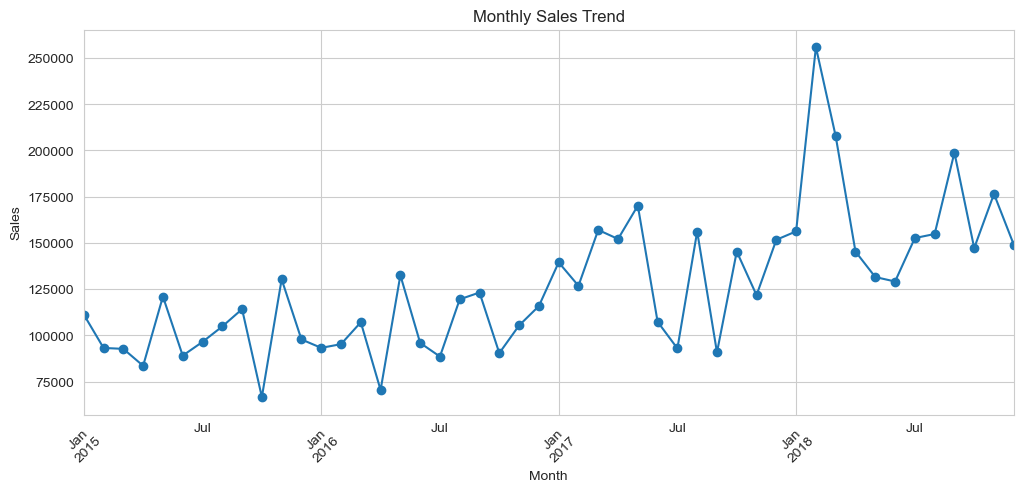

In [39]:
# Monthly Sales Trend

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

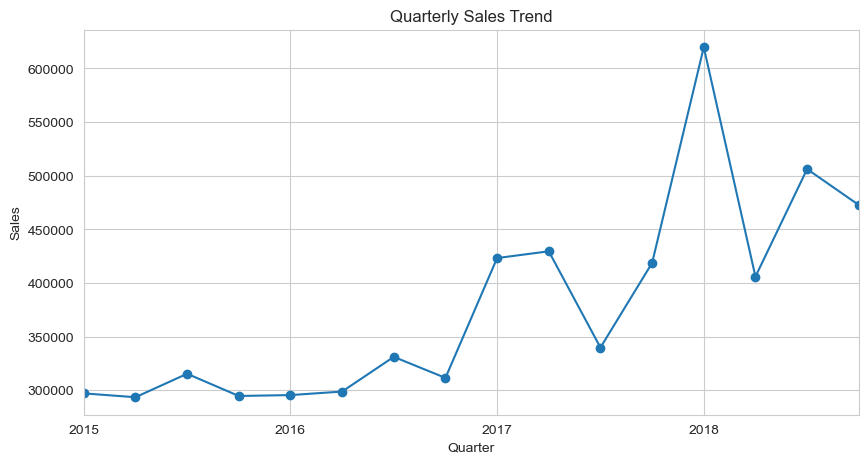

In [40]:
# Quarterly Sales Trend

quarterly_sales = df.groupby(df["Order Date"].dt.to_period("Q"))["Sales"].sum()

plt.figure(figsize=(10,5))

quarterly_sales.plot(marker='o')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

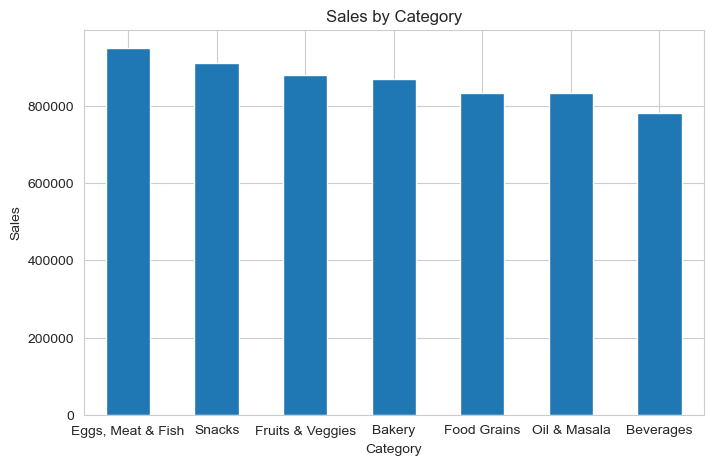

In [41]:
# Sales by Category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Observation

Technology, Furniture, and Office Supplies contribute differently to total sales. The highest-selling category generates the largest share of revenue.

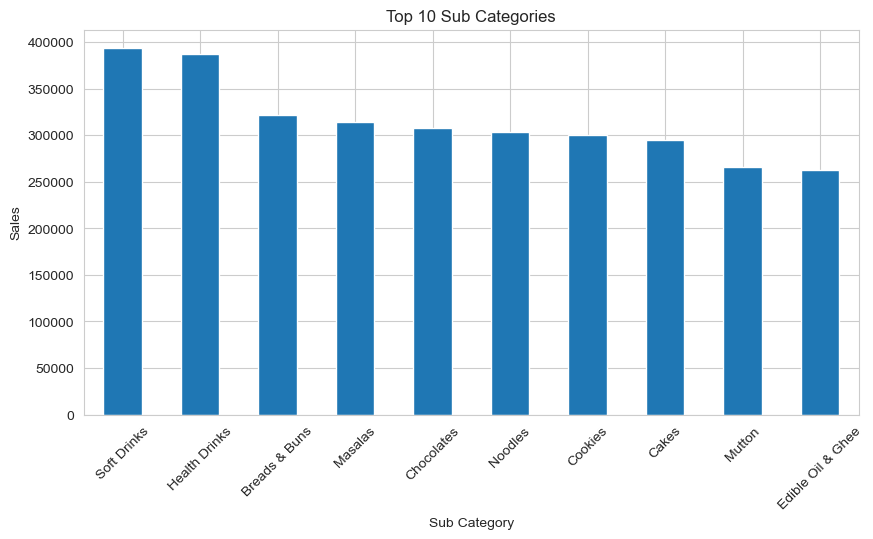

In [42]:
# Top 10 Sub Categories

top_sub = df.groupby("Sub Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_sub.plot(kind='bar')

plt.title("Top 10 Sub Categories")
plt.xlabel("Sub Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## Observation

The top-performing sub-categories generate the highest sales and should be prioritized for inventory management and promotional campaigns.

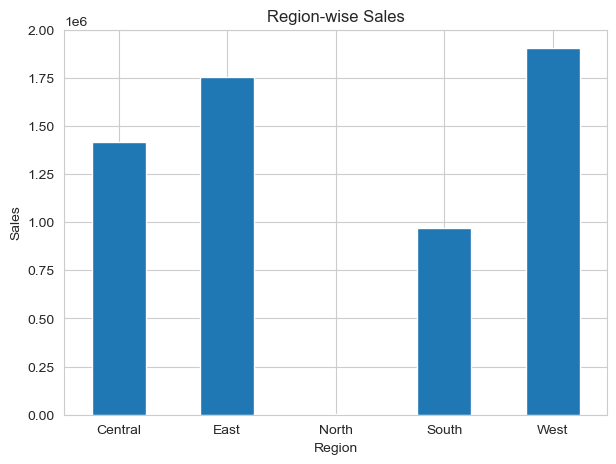

In [44]:
# Region-wise Sales

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,5))

region_sales.plot(kind='bar')

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Observation

The regional analysis identifies which regions contribute the most to overall sales and which regions require additional marketing efforts.

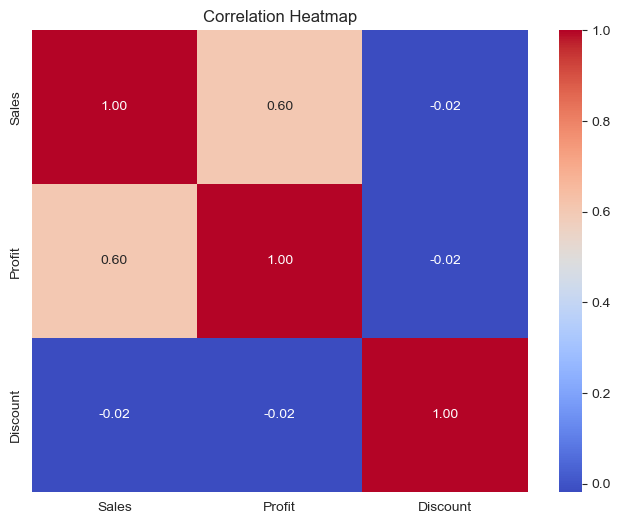

In [45]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales", "Profit", "Discount"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap illustrates the relationship between Sales, Profit, and Discount. It helps identify whether discounts positively or negatively affect profitability.

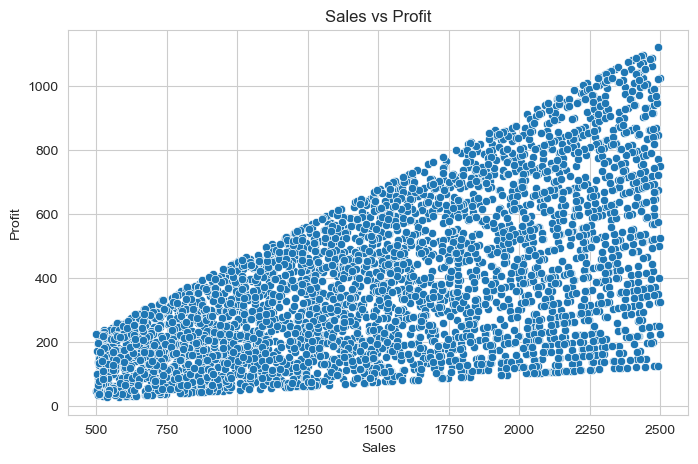

In [46]:
# Sales vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")

plt.show()

## Observation

Most high-value sales generate higher profits, while a few transactions with high sales still result in low or negative profit, indicating heavy discounts or high costs.

# Conclusion

## Key Findings

- Monthly and quarterly sales show seasonal variations.
- Technology and Office Supplies contribute significantly to revenue.
- Some sub-categories consistently outperform others.
- Regional analysis highlights the strongest sales markets.
- Sales and Profit are positively related, while excessive discounts can reduce profitability.

## Business Recommendations

1. Increase inventory for top-performing categories and sub-categories.
2. Plan marketing campaigns during peak sales months.
3. Optimize discount strategies to improve profit margins.
4. Focus promotional efforts on regions with lower sales performance.
5. Monitor low-profit transactions to reduce unnecessary losses.